# 🎨 Data Visualization Part 2: Advanced Matplotlib & Pandas Plotting
**From Annotations to 3D Plots, Heatmaps, and the Pandas `.plot()` API**

Welcome to Part 2! In Part 1, we learned the basic chart types. Today, we elevate our skills to **storytelling** and **multidimensional analysis**. We will master custom annotations, subplots, 3D visualizations, heatmaps, and finally, the incredibly fast **Pandas built-in plotting API**.

Every concept follows our **Mastery Framework**:
`Theory → Mental Model → Diagram → Code → Mistakes → Interview → Practice (Levels 1-5)`


In [1]:
# ==========================================
# 🛠️ SETUP & DATASETS
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D # For 3D plots

print(f"Matplotlib Version: {plt.matplotlib.__version__}")

# 1. Stocks Dataset (from transcript)
url = 'https://raw.githubusercontent.com/m-mehdi/pandas_tutorials/main/weekly_stocks.csv'
try:
    stocks = pd.read_csv(url)
    print("✅ Stocks dataset loaded.")
except:
    # Fallback mock data if URL fails
    stocks = pd.DataFrame({
        'MSFT': np.random.randn(50).cumsum() + 100,
        'AAPL': np.random.randn(50).cumsum() + 150,
        'GOOG': np.random.randn(50).cumsum() + 200,
        'Volume': np.random.randint(1000, 5000, 50)
    })
    print("✅ Mock Stocks dataset created.")

# 2. Tips Dataset (Seaborn)
tips = sns.load_dataset('tips')
print("✅ Tips dataset loaded.")


Matplotlib Version: 3.10.9
✅ Stocks dataset loaded.
✅ Tips dataset loaded.


# 📘 Module 1: Advanced Customizations (Scatter, Size, Annotations, Lines)

## 🧠 1. Theory & Mental Model
A basic plot shows data; a **customized plot tells a story**. 
- **Colored Scatter:** Maps a 3rd or 4th variable to color/size.
- **Annotations:** Pointing out specific anomalies or peaks.
- **Axlines:** Drawing thresholds (e.g., "Average", "Target").

## 📊 2. Visual Diagram
```text
      ↑ Price
      |      / \
  150 |-----/---\-------  ← plt.axhline (Target)
      |    *     \
  100 |   / \     \
      |  /   *-----\--   ← plt.annotate (Peak)
      +----------------→ Time
```


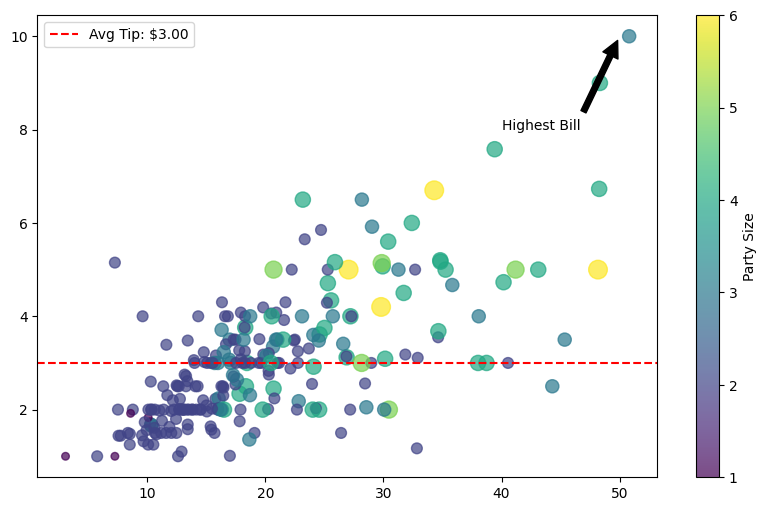

In [2]:
# Colored Scatter with Alpha & Cmap
plt.figure(figsize=(10, 6))
scatter = plt.scatter(tips['total_bill'], tips['tip'], 
                      c=tips['size'], cmap='viridis', alpha=0.7, s=tips['size']*30)
plt.colorbar(scatter, label='Party Size')

# Horizontal Line (Average Tip)
avg_tip = tips['tip'].mean()
plt.axhline(avg_tip, color='red', linestyle='--', label=f'Avg Tip: ${avg_tip:.2f}')

# Annotation
plt.annotate('Highest Bill', xy=(50, 10), xytext=(40, 8),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.legend()
plt.show()


## ⚠️ 4. Common Mistakes
Forgetting `alpha=0.7` in dense scatter plots. Without transparency, overlapping points hide the true density of the data (Overplotting).

## 🎤 5. Interview Question
**Q:** What is the difference between `plt.text()` and `plt.annotate()`?
**A:** `plt.text()` simply places text at an (x, y) coordinate. `plt.annotate()` can place text *and* draw an arrow pointing to a specific data point, and it supports different coordinate systems (data, axes, or figure coordinates).

## 🎯 6. Practice Tasks
*   **Level 1 (Easy):** Create a scatter plot of `tips` mapping `color='red'` and `alpha=0.5`.
*   **Level 2 (Medium):** Add a vertical line (`plt.axvline`) at `total_bill = 30`.
*   **Level 3 (Hard):** Map the `size` column to the color (`c`) using the `plasma` colormap.
*   **Level 4 (Expert):** Annotate the exact coordinate of the highest `total_bill` with an arrow.
*   **Level 5 (Challenge):** Set the plot size to `figsize=(12, 8)` and `dpi=150` for high resolution.


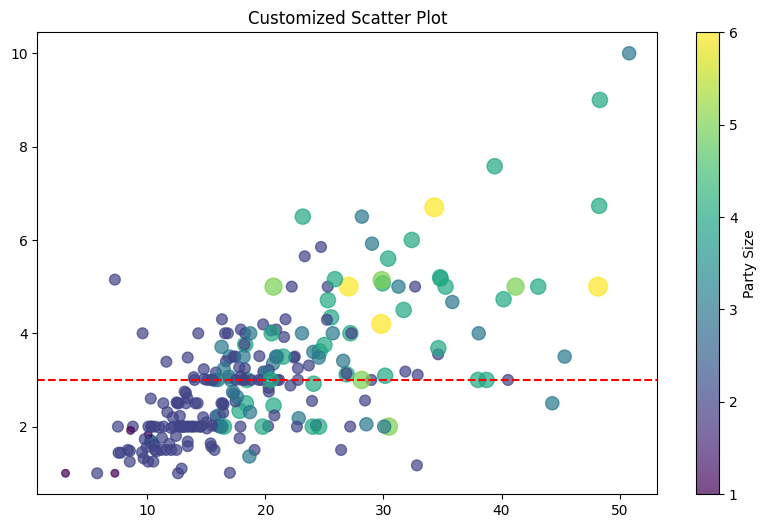

In [3]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 1
# ==========================================
# Example Execution
plt.figure(figsize=(10, 6))
scatter = plt.scatter(tips['total_bill'], tips['tip'], c=tips['size'], cmap='viridis', alpha=0.7, s=tips['size']*30)
plt.colorbar(scatter, label='Party Size')
plt.axhline(tips['tip'].mean(), color='red', linestyle='--')
plt.title("Customized Scatter Plot")
plt.show()

# --- YOUR TURN ---
# Level 1: Basic scatter with alpha
# Level 2: Add axvline at x=30
# Level 3: Map 'size' to color with 'plasma'
# Level 4: Annotate max total_bill
# Level 5: figsize and dpi


# 📘 Module 2: Subplots (Dashboards)

## 🧠 1. Theory & Mental Model
**Subplots** allow you to place multiple charts in a single figure grid. 
**Mental Model:** A **Comic Book Page**. The `Figure` is the page, and the `Axes` are the individual panels.

## 🛠️ 2. Syntax
```python
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes[0, 0].plot(...) # Top-Left
axes[0, 1].scatter(...) # Top-Right
plt.tight_layout() # Prevents overlapping labels!
```

## ⚠️ 3. Common Mistakes
Forgetting `plt.tight_layout()`. Without it, axis labels and titles from adjacent subplots will crash into each other.

## 🎤 4. Interview Question
**Q:** How do you share the X-axis across all subplots?
**A:** Pass `sharex=True` in `plt.subplots()`. This is crucial for time-series comparison so the scales align perfectly.

## 🎯 5. Practice Tasks
*   **Level 1:** Create a 1x2 subplot grid (1 row, 2 columns).
*   **Level 2:** Plot `MSFT` on the left, `AAPL` on the right.
*   **Level 3:** Create a 2x2 grid. Plot Line, Scatter, Bar, and Hist in the 4 quadrants.
*   **Level 4:** Use `sharex=True` and `sharey=True` to compare `MSFT` and `AAPL` directly.
*   **Level 5:** Add a main title to the entire figure using `fig.suptitle("Stock Dashboard")`.


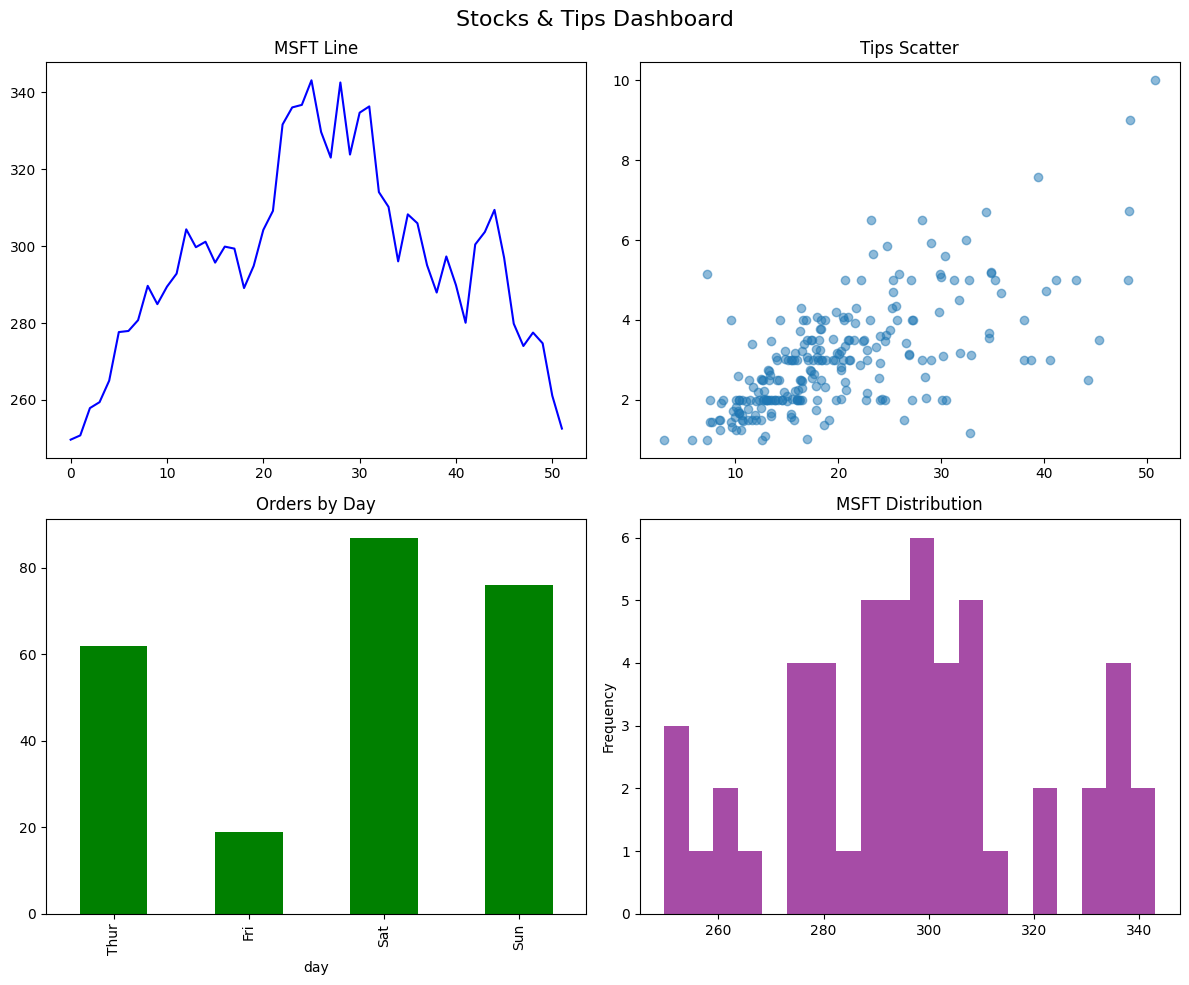

In [4]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 2
# ==========================================
# Example Execution: 2x2 Dashboard
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Stocks & Tips Dashboard", fontsize=16)

# Top-Left: Line
axes[0, 0].plot(stocks['MSFT'], color='blue')
axes[0, 0].set_title("MSFT Line")

# Top-Right: Scatter
axes[0, 1].scatter(tips['total_bill'], tips['tip'], alpha=0.5)
axes[0, 1].set_title("Tips Scatter")

# Bottom-Left: Bar
tips.groupby('day').size().plot(kind='bar', ax=axes[1, 0], color='green')
axes[1, 0].set_title("Orders by Day")

# Bottom-Right: Histogram
stocks['MSFT'].plot(kind='hist', ax=axes[1, 1], bins=20, color='purple', alpha=0.7)
axes[1, 1].set_title("MSFT Distribution")

plt.tight_layout()
plt.show()

# --- YOUR TURN ---
# Level 1-5: Build your own 2x2 dashboard!


---

# 📘 Module 3: 3D Visualizations & Heatmaps

## 🧠 1. Theory & Mental Model
When data has 3 numerical dimensions $(X, Y, Z)$, 2D plots fail. We need 3D space or top-down projections (Heatmaps/Contours).
- **3D Scatter/Line:** Points in space.
- **3D Surface:** A continuous "skin" over $(X, Y)$ mapped to $Z$.
- **Contour:** Top-down view of a surface (like a topographic map).
- **Heatmap:** A 2D matrix where color represents intensity.

## 💻 2. Code Example (3D & Contour)


NameError: name 'x' is not defined

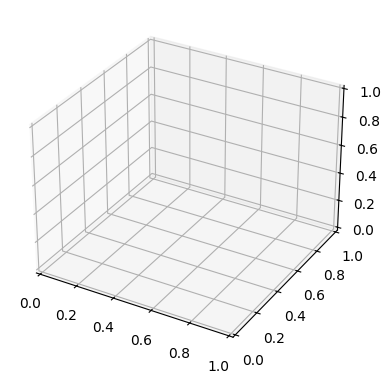

In [5]:
fig = plt.figure(figsize=(15, 10))

# 1. 3D Scatter
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.scatter3D(x, y, z, c=z, cmap='viridis')

# 2. 3D Surface
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))
ax2.plot_surface(X, Y, Z, cmap='coolwarm')

# 3. Contour Fill
ax3 = fig.add_subplot(2, 2, 3)
ax3.contourf(X, Y, Z, cmap='coolwarm') # Top-down view!

# 4. Heatmap (imshow)
ax4 = fig.add_subplot(2, 2, 4)
im = ax4.imshow(Z, cmap='hot', interpolation='nearest')
plt.colorbar(im, ax=ax4)


## 🎤 3. Interview Question
**Q:** When should you use a Contour plot vs a 3D Surface plot?
**A:** Use 3D Surface for visual impact and showing the "shape" of the data. Use Contour/Heatmaps for **precise analysis**, as 3D plots can suffer from perspective distortion and occlusion (points hiding behind other points).

## 🎯 4. Practice Tasks
*   **Level 1:** Generate $X, Y$ using `np.meshgrid` and calculate $Z = X^2 + Y^2$.
*   **Level 2:** Plot a 3D Scatter of $X, Y, Z$.
*   **Level 3:** Plot a 3D Surface of the same data using `cmap='plasma'`.
*   **Level 4:** Create a `contourf` plot and add a colorbar.
*   **Level 5:** Create a Heatmap of a correlation matrix using `plt.imshow(stocks.corr(), cmap='coolwarm')`.


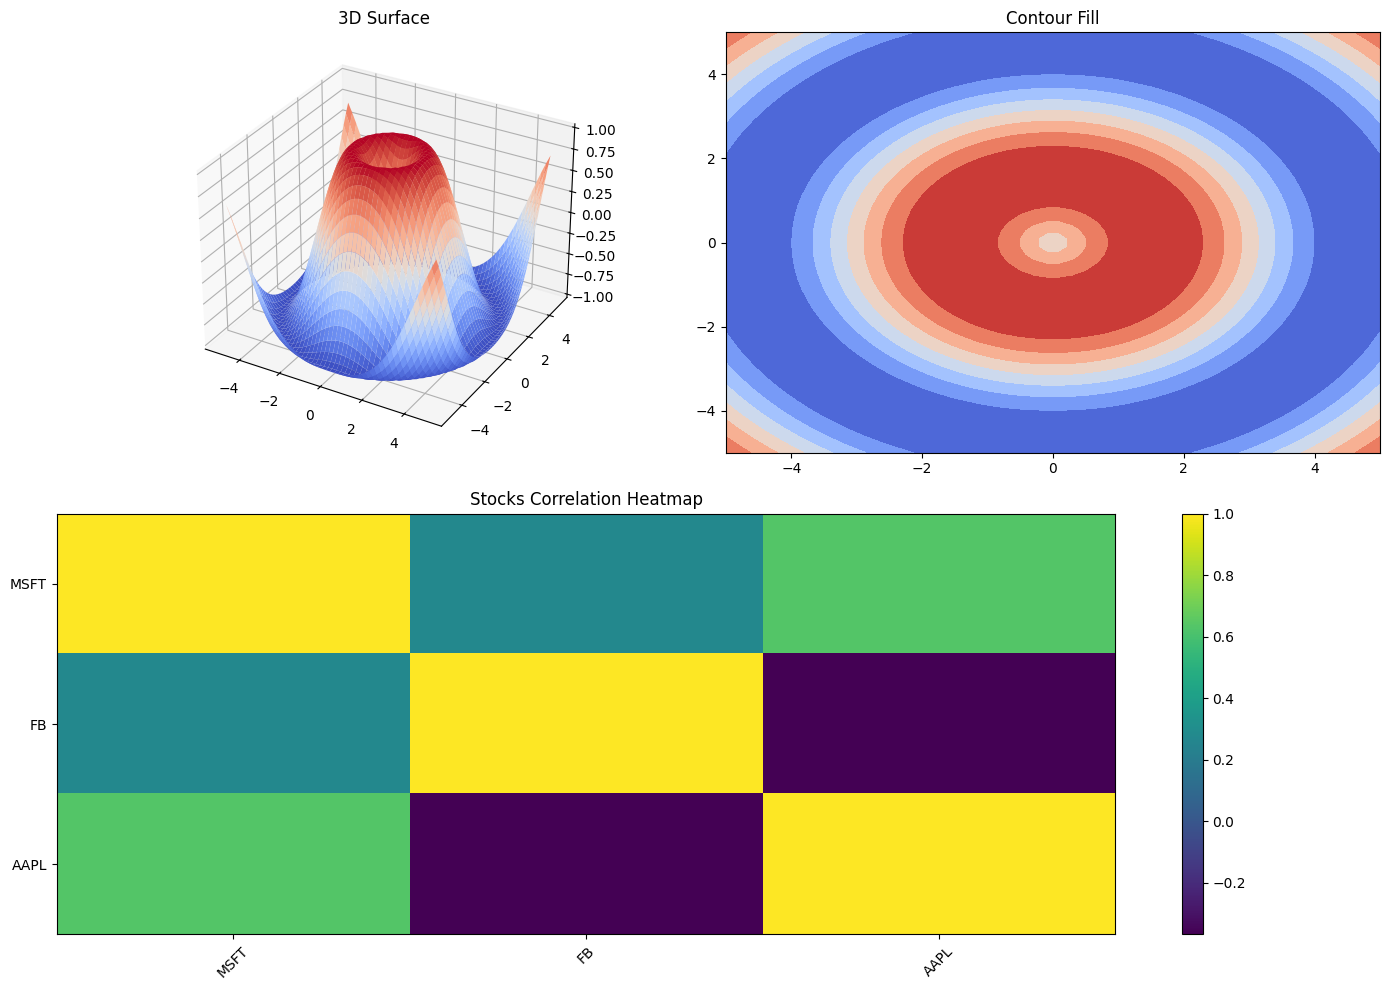

In [6]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 3
# ==========================================
# Generate Data
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

fig = plt.figure(figsize=(14, 10))

# 3D Surface
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none')
ax1.set_title('3D Surface')

# Contour Fill
ax2 = fig.add_subplot(2, 2, 2)
ax2.contourf(X, Y, Z, cmap='coolwarm')
ax2.set_title('Contour Fill')

# Heatmap (Correlation)
ax3 = fig.add_subplot(2, 1, 2)
# Using numeric columns from stocks
corr_matrix = stocks.select_dtypes(include=[np.number]).corr()
im = ax3.imshow(corr_matrix, cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax3)
ax3.set_title('Stocks Correlation Heatmap')
ax3.set_xticks(range(len(corr_matrix.columns)))
ax3.set_xticklabels(corr_matrix.columns, rotation=45)
ax3.set_yticks(range(len(corr_matrix.index)))
ax3.set_yticklabels(corr_matrix.index)

plt.tight_layout()
plt.show()

# --- YOUR TURN ---
# Level 1-5: Experiment with meshgrid and 3D plots!


---

# 📘 Module 4: Pandas `.plot()` API Masterclass

## 🧠 1. Theory & Mental Model
Writing Matplotlib code for quick EDA (Exploratory Data Analysis) is slow. **Pandas `.plot()`** is a wrapper around Matplotlib that lets you plot directly from DataFrames and Series with a single keyword argument: `kind`.

## 🛠️ 2. Syntax Cheat Sheet
```python
df.plot(kind='line')      # Line
df.plot(kind='bar')       # Vertical Bar
df.plot(kind='barh')      # Horizontal Bar
df.plot(kind='hist')      # Histogram
df.plot(kind='box')       # Boxplot
df.plot(kind='scatter', x='col1', y='col2') # Scatter
df.plot(kind='pie')       # Pie Chart
```

## 💡 3. Fun Fact
Under the hood, `df.plot()` literally calls `plt.plot()`. It just automatically extracts the index for the X-axis and the column names for the labels!

## 🎯 4. Practice Tasks
*   **Level 1:** Plot a line chart of `stocks['MSFT']` using `.plot()`.
*   **Level 2:** Plot a horizontal bar chart of total tips by `day`.
*   **Level 3:** Plot a stacked bar chart of `total_bill` by `day`, stacked by `time` (Lunch/Dinner).
*   **Level 4:** Plot a histogram of `stocks['AAPL']` with 30 bins.
*   **Level 5:** Plot a scatter chart of `MSFT` vs `AAPL`, coloring by `Volume`.


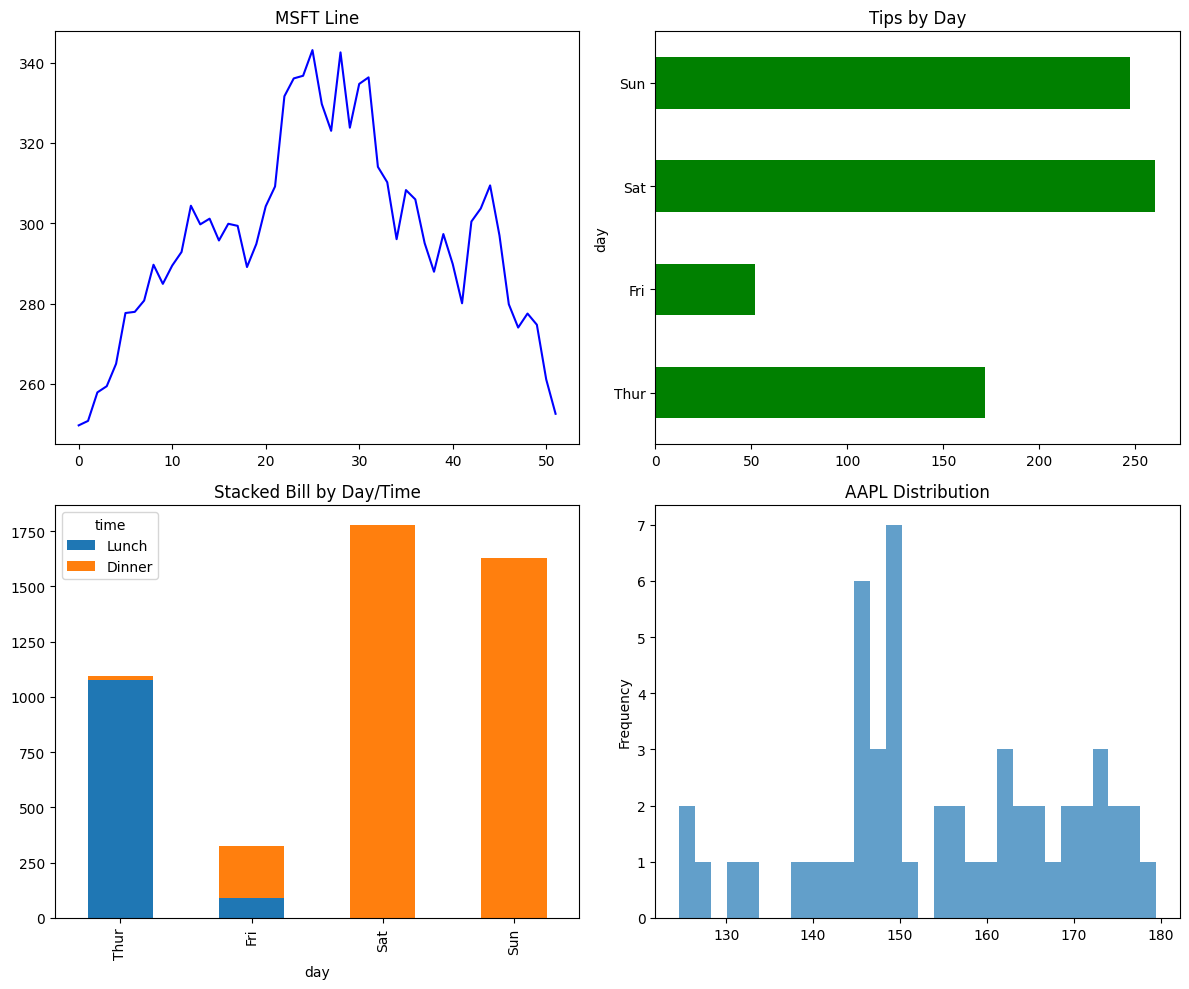

In [7]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 4
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Line Plot (Series)
stocks['MSFT'].plot(kind='line', ax=axes[0, 0], color='blue', title="MSFT Line")

# 2. Horizontal Bar Chart
tips.groupby('day')['tip'].sum().plot(kind='barh', ax=axes[0, 1], color='green', title="Tips by Day")

# 3. Stacked Bar Chart
pivot_stacked = tips.pivot_table(values='total_bill', index='day', columns='time', aggfunc='sum')
pivot_stacked.plot(kind='bar', stacked=True, ax=axes[1, 0], title="Stacked Bill by Day/Time")

# 4. Histogram
stocks['AAPL'].plot(kind='hist', bins=30, ax=axes[1, 1], alpha=0.7, title="AAPL Distribution")

plt.tight_layout()
plt.show()

# --- YOUR TURN ---
# Level 1-5: Try the Pandas .plot() API!


---

# 📘 Module 5: Pie Charts & MultiIndex Plotting

## 🧠 1. Theory: Pie Charts in Pandas
Pandas makes pie charts incredibly easy, but they should only be used for **part-to-whole** relationships with $\le 5$ categories.

## 🛠️ 2. Syntax
```python
# Single Pie
df['col'].value_counts().plot(kind='pie')

# Multiple Pies (Subplots)
df.plot(kind='pie', subplots=True, figsize=(10, 5))
```

## 🌍 3. Real-World Scenario: MultiIndex Pie Charts
What if you want to see the proportion of Lunch vs Dinner for *every single day*? You group by two columns to create a **MultiIndex Series**, then `unstack()` it into a DataFrame, and plot `subplots=True`.

## 💻 4. Code Example


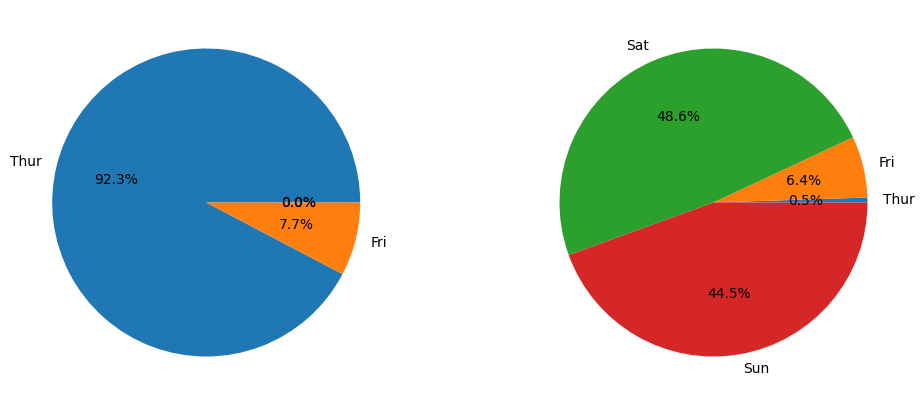

In [8]:
# Create MultiIndex Series
mi_data = tips.groupby(['day', 'time'])['total_bill'].sum()

# Unstack so 'time' becomes columns, 'day' becomes rows
# Then plot as multiple pie charts!
mi_data.unstack().plot(kind='pie', subplots=True, figsize=(12, 5), 
                       autopct='%1.1f%%', legend=False)
plt.show()


## ⚠️ 5. Common Mistakes
Plotting a pie chart directly on a raw DataFrame with numerical columns (e.g., `stocks.plot(kind='pie')`). This will try to sum the *rows* and make a pie out of every single week's data, resulting in 50 invisible pies! Always `groupby()` or `value_counts()` first.

## 🎯 6. Practice Tasks
*   **Level 1:** Plot a single pie chart of `tips['day']` value counts.
*   **Level 2:** Add `autopct='%1.1f%%'` to show percentages.
*   **Level 3:** "Explode" the largest slice by 0.1.
*   **Level 4:** Create a MultiIndex Series of `tips` grouped by `['sex', 'smoker']` and plot it as multiple pies.
*   **Level 5:** Create a stacked bar chart and a pie chart side-by-side comparing the same data to see which is easier to read.


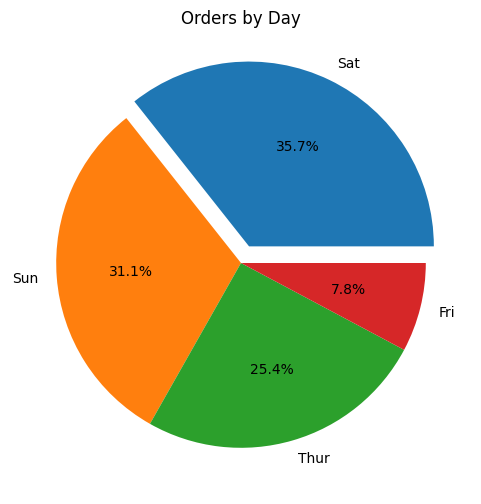

TypeError: Axes.pie() got an unexpected keyword argument 'axes'

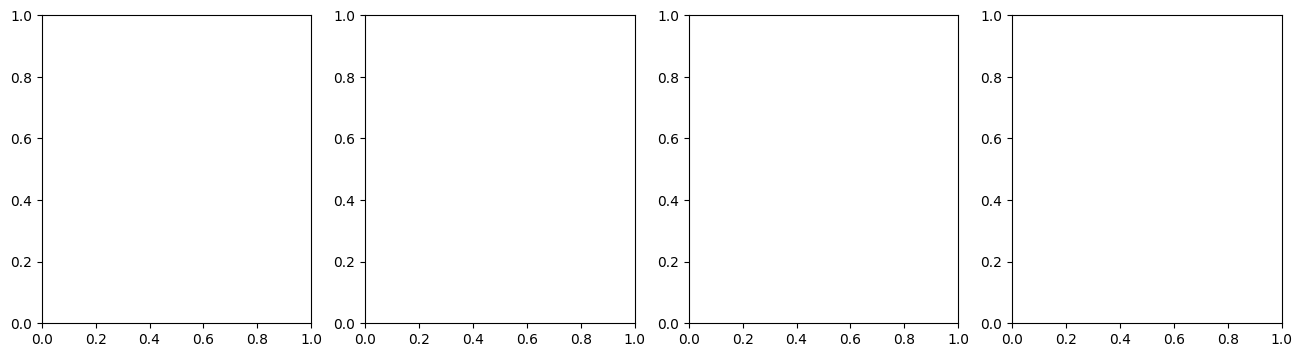

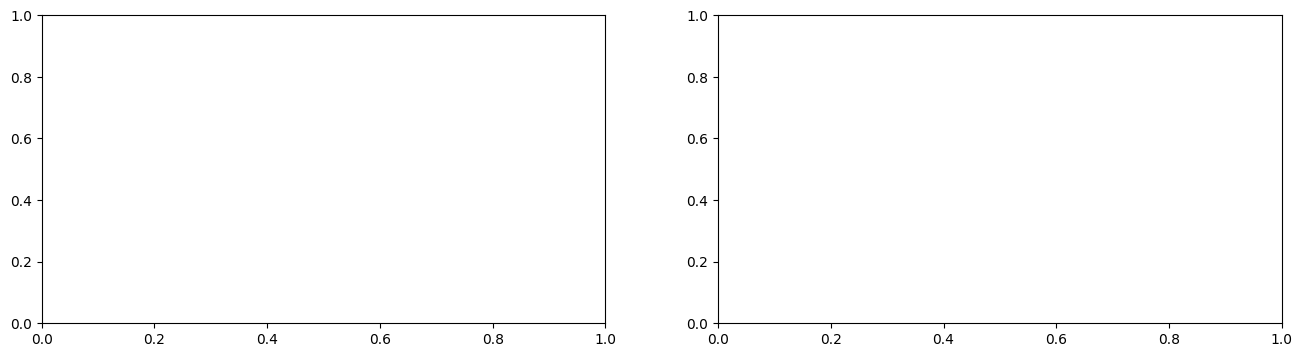

In [9]:
# ==========================================
# 💻 CODE & PRACTICE: MODULE 5
# ==========================================
# Single Pie
plt.figure(figsize=(6, 6))
tips['day'].value_counts().plot(kind='pie', autopct='%1.1f%%', explode=[0.1, 0, 0, 0])
plt.ylabel('') # Hide ugly Y-label
plt.title("Orders by Day")
plt.show()

# MultiIndex Pie Charts
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
mi_data = tips.groupby(['day', 'time'])['total_bill'].sum().unstack()
mi_data.plot(kind='pie', subplots=True, axes=axes, autopct='%1.1f%%', legend=False, figsize=(16, 4))
plt.suptitle("Lunch vs Dinner Proportions by Day", fontsize=16)
plt.tight_layout()
plt.show()

# --- YOUR TURN ---
# Level 1-5: Master the Pie Chart and MultiIndex plotting!


# 🎉 Congratulations!
You have mastered **Data Visualization Part 2**.
You now know how to:
✅ Customize plots with Annotations, Axlines, and Colormaps.
✅ Build complex Dashboards using Subplots.
✅ Visualize multidimensional data with 3D Plots, Contours, and Heatmaps.
✅ Perform lightning-fast EDA using the **Pandas `.plot()` API**.
✅ Handle complex hierarchical data with MultiIndex Pie Charts.

### 🚀 Next Steps
You are now ready for **Data Visualization Part 3: Seaborn & Plotly** – Statistical plotting, interactive dashboards, and geospatial maps!
